In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.0 MB/s eta 0:00:00a 0:00:01


In [2]:
!nvidia-smi

Tue May 26 07:38:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print("YOLOv8 Installed Successfully")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 Installed Successfully


In [10]:
import os

print(os.listdir('/kaggle/input'))

['datasets', 'notebooks']


In [14]:
import os

path = "/kaggle/input/datasets/ronakgohil/license-plate-dataset/archive"

print(os.listdir(path))

['dataset.yaml', 'labels', 'images', 'classes.txt']


In [15]:
!pip install ultralytics

In [18]:
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO("yolov8n.pt")

# Train the model
model.train(
    data="/kaggle/input/datasets/ronakgohil/license-plate-dataset/archive/dataset.yaml",
    epochs=20,
    imgsz=640
)

Ultralytics 8.4.54 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/ronakgohil/license-plate-dataset/archive/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False,

RuntimeError: Dataset '/kaggle/input/datasets/ronakgohil/license-plate-dataset/archive/dataset.yaml' error ❌ /kaggle/input/datasets/ronakgohil/license-plate-dataset/archive/dataset.yaml 'names' length 1 and 'nc: 1,' must match.

In [19]:
content = """
path: /kaggle/input/datasets/ronakgohil/license-plate-dataset/archive

train: images
val: images

nc: 1

names: ['license_plate']
"""

with open("/kaggle/working/dataset.yaml", "w") as f:
    f.write(content)

print("Fixed dataset.yaml created")

Fixed dataset.yaml created


In [20]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/kaggle/working/dataset.yaml",
    epochs=20,
    imgsz=640
)

Ultralytics 8.4.54 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dc8dcc02f00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [22]:
from ultralytics import YOLO

# Load trained model
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')

# Run prediction
model.predict(
    source='/kaggle/input/datasets/ronakgohil/license-plate-dataset/archive/images',
    save=True,
    conf=0.25
)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/runs/detect/train/weights/best.pt'

In [23]:
from ultralytics import YOLO

# Load trained model
model = YOLO('/kaggle/working/runs/detect/train-4/weights/best.pt')

# Run prediction
model.predict(
    source='/kaggle/input/datasets/ronakgohil/license-plate-dataset/archive/images',
    save=True,
    conf=0.25
)

FileNotFoundError: No images or videos found in /kaggle/input/datasets/ronakgohil/license-plate-dataset/archive/images. Supported formats are:
images: {'mpo', 'jpg', 'dng', 'tif', 'bmp', 'jpeg', 'jp2', 'png', 'heif', 'tiff', 'webp', 'heic', 'jpeg2000', 'avif'}
videos: {'mpeg', 'asf', 'ts', 'wmv', 'mp4', 'mpg', 'avi', 'mov', 'mkv', 'gif', 'webm', 'm4v'}

In [24]:
import os

path = "/kaggle/input/datasets/ronakgohil/license-plate-dataset/archive/images"

print(os.listdir(path))

['val', 'train']


In [ ]:
from ultralytics import YOLO

model = YOLO('/kaggle/working/runs/detect/train-4/weights/best.pt')

model.predict(
    source='/kaggle/input/datasets/ronakgohil/license-plate-dataset/archive/images/train',
    save=True,
    conf=0.25
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1526 /kaggle/input/datasets/ronakgohil/license-plate-dataset/archive/images/train/0073797c-a755-4972-b76b-8ef2b31d44ab___new_IMG_20160315_071740.jpg.jpg: 448x640 1 license_plate, 44.5ms
image 2/1526 /kaggle/input/datasets/ronakgohil/license-plate-dataset/archive/images/train/00b42b2c-f193-4863-b92c-0245cbc816da___3e7fd381-0ae5-4421-8a70-279ee0ec1c61_Nissan-Terrano-Petrol-Review-Images-Black-Front-Angle.jpg: 448x640 1 license_plate, 5.9ms
image 3/

In [26]:
!pip install easyocr


0: 416x640 1 license_plate, 7.6ms
Speed: 2.5ms preprocess, 7.6ms inference, 1.2ms postprocess per image at shape (1, 3, 416, 640)
Detected Text: [([[np.int32(41), np.int32(10)], [489, np.int32(10)], [489, np.int32(125)], [np.int32(41), np.int32(125)]], 'MHO2DN8718', np.float64(0.8287819429368868))]


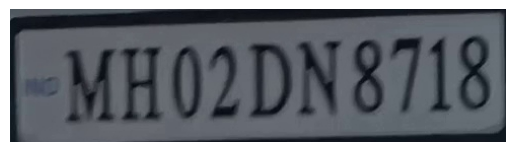

In [27]:
import cv2
import easyocr
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Load trained YOLO model
model = YOLO('/kaggle/working/runs/detect/train-4/weights/best.pt')

# Load image
image_path = '/kaggle/input/datasets/ronakgohil/license-plate-dataset/archive/images/train/video2_280.jpg'

img = cv2.imread(image_path)

# Detect number plate
results = model(img)

# OCR reader
reader = easyocr.Reader(['en'])

for result in results:
    boxes = result.boxes.xyxy.cpu().numpy()

    for box in boxes:
        x1, y1, x2, y2 = map(int, box)

        # Crop plate
        plate = img[y1:y2, x1:x2]

        # OCR text reading
        text = reader.readtext(plate)

        print("Detected Text:", text)

        # Show cropped plate
        plt.imshow(cv2.cvtColor(plate, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()